In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Data Augmentation and Normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Download CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:05<00:00, 32.7MB/s]


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

# This pulls the real dataset from the web
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to('cuda') # Send model to GPU

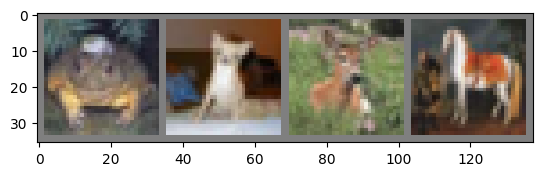

Labels: frog  dog   deer  horse


In [ ]:
import numpy as np

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5     # Unnormalize (back to [0, 1] range)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Change from (C, H, W) to (H, W, C)
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images & print labels
imshow(torchvision.utils.make_grid(images[:4])) # Show first 4 images
print('Labels:', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [ ]:
# Check if a GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Print what we found (in Colab, this should say 'cuda')
print(f"Using device: {device}")

# Move your model to that device
model.to(device)

Using device: cuda


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [ ]:
from torchvision import models

# 1. Load pretrained ResNet
resnet_model = models.resnet18(weights='DEFAULT')

# 2. Freeze the 'features' (don't retrain the whole thing, just the end)
for param in resnet_model.parameters():
    param.requires_grad = False

# 3. Replace the final layer for CIFAR-10 (10 classes)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 10)

# 4. Move to GPU and train ONLY the new layer
resnet_model = resnet_model.to(device)
optimizer_resnet = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

print("Starting Training: ResNet18 (Transfer Learning)...")
train_model(resnet_model, trainloader, criterion, optimizer_resnet, epochs=5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


Starting Training: ResNet18 (Transfer Learning)...
[1,   200] loss: 1.915
[1,   400] loss: 1.700
[1,   600] loss: 1.647
[2,   200] loss: 1.595
[2,   400] loss: 1.616
[2,   600] loss: 1.601
[3,   200] loss: 1.574
[3,   400] loss: 1.587
[3,   600] loss: 1.570
[4,   200] loss: 1.562
[4,   400] loss: 1.581
[4,   600] loss: 1.578
[5,   200] loss: 1.553
[5,   400] loss: 1.579
[5,   600] loss: 1.587
Finished Training


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def evaluate_accuracy(model, loader):
    model.eval() # Set model to evaluation mode (turns off Dropout/BatchNorm updates)
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Disable gradient calculation to save memory/speed
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Store predictions for the Confusion Matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    return acc, all_labels, all_preds

print("Function 'evaluate_accuracy' is now defined and ready!")

Function 'evaluate_accuracy' is now defined and ready!


In [ ]:
# Evaluate your Custom Simple CNN
acc_simple, true_labels_simple, pred_labels_simple = evaluate_accuracy(model, testloader)

# Evaluate the ResNet18 Transfer Learning model
acc_resnet, true_labels_resnet, pred_labels_resnet = evaluate_accuracy(resnet_model, testloader)

print(f"--- Final Comparison ---")
print(f"Custom Simple CNN Accuracy: {acc_simple:.2f}%")
print(f"ResNet18 Transfer Learning Accuracy: {acc_resnet:.2f}%")

--- Final Comparison ---
Custom Simple CNN Accuracy: 9.92%
ResNet18 Transfer Learning Accuracy: 42.96%


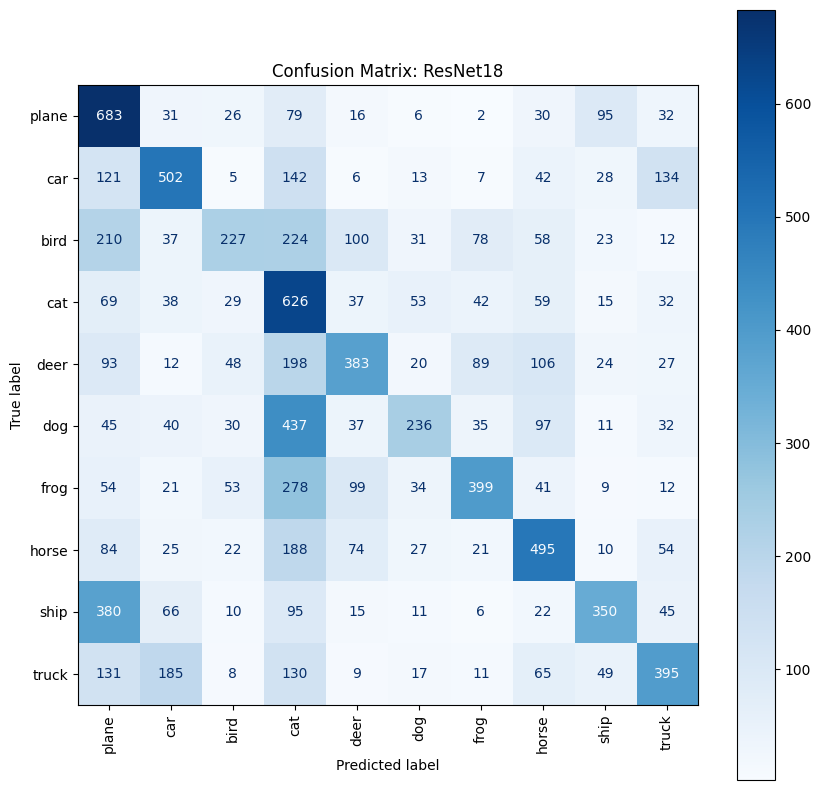

In [ ]:
import matplotlib.pyplot as plt

# Plot Confusion Matrix for ResNet (usually the better model)
cm = confusion_matrix(true_labels_resnet, pred_labels_resnet)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix: ResNet18")
plt.show()

In [ ]:
# Run this if the first one still gives errors
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset # This uses the HuggingFace library (very stable)

# 1. Load dataset
dataset = load_dataset("imdb")

# 2. Basic Tokenizer
def tokenize(text):
    return text.lower().split()

# 3. Build Vocab manually (Cleaner and no torchtext errors)
word_to_idx = {"<pad>": 0, "<unk>": 1}
for example in dataset['train']['text'][:5000]: # Build from first 5000 samples for speed
    for word in tokenize(example):
        if word not in word_to_idx:
            word_to_idx[word] = len(word_to_idx)

print(f"Vocab size: {len(word_to_idx)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Vocab size: 88256


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

MAX_LEN = 200  # We will look at the first 200 words of each review

def encode_and_pad(text):
    tokens = tokenize(text)[:MAX_LEN]
    # Convert words to indices, use <unk> (index 1) if word not in vocab
    encoded = [word_to_idx.get(w, 1) for w in tokens]
    # Pad with 0 if shorter than MAX_LEN
    padded = encoded + [0] * (MAX_LEN - len(encoded))
    return torch.tensor(padded)

def collate_fn(batch):
    texts = [encode_and_pad(item['text']) for item in batch]
    labels = [item['label'] for item in batch]
    # labels in IMDB are 0 (neg) and 1 (pos)
    return torch.stack(texts), torch.tensor(labels, dtype=torch.float32)

# Create DataLoaders
# We use a smaller subset of data for training speed in this lab
train_loader = DataLoader(dataset['train'].select(range(5000)), batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(dataset['test'].select(range(1000)), batch_size=32, shuffle=False, collate_fn=collate_fn)

print("DataLoaders are ready!")

DataLoaders are ready!


In [ ]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, rnn_type='LSTM'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        if rnn_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        else: # LSTM
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        # We only care about the final hidden state output
        if isinstance(self.rnn, nn.LSTM):
            _, (hidden, _) = self.rnn(x)
        else:
            _, hidden = self.rnn(x)

        # hidden shape is (num_layers, batch, hidden_dim)
        # We take the last layer's hidden state
        return self.sigmoid(self.fc(hidden[-1])).squeeze()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = len(word_to_idx)

import torch.optim as optim

def train_and_get_losses(rnn_name):
    print(f"Training {rnn_name}...")
    model = TextClassifier(vocab_size, 64, 128, rnn_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    loss_history = []
    model.train()

    for epoch in range(5): # 5 epochs to see clear trends
        epoch_loss = 0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f}")

    return loss_history

# Compare them! (This will take a few minutes)
results = {
    'RNN': train_and_get_losses('RNN'),
    'LSTM': train_and_get_losses('LSTM'),
    'GRU': train_and_get_losses('GRU')
}

Training RNN...
Epoch 1 - Avg Loss: 0.0654
Epoch 2 - Avg Loss: 0.0303
Epoch 3 - Avg Loss: 0.0066
Epoch 4 - Avg Loss: 0.0034
Epoch 5 - Avg Loss: 0.0018
Training LSTM...
Epoch 1 - Avg Loss: 0.0616
Epoch 2 - Avg Loss: 0.0002
Epoch 3 - Avg Loss: 0.0001
Epoch 4 - Avg Loss: 0.0001
Epoch 5 - Avg Loss: 0.0001
Training GRU...
Epoch 1 - Avg Loss: 0.0614
Epoch 2 - Avg Loss: 0.0003
Epoch 3 - Avg Loss: 0.0002
Epoch 4 - Avg Loss: 0.0001
Epoch 5 - Avg Loss: 0.0001


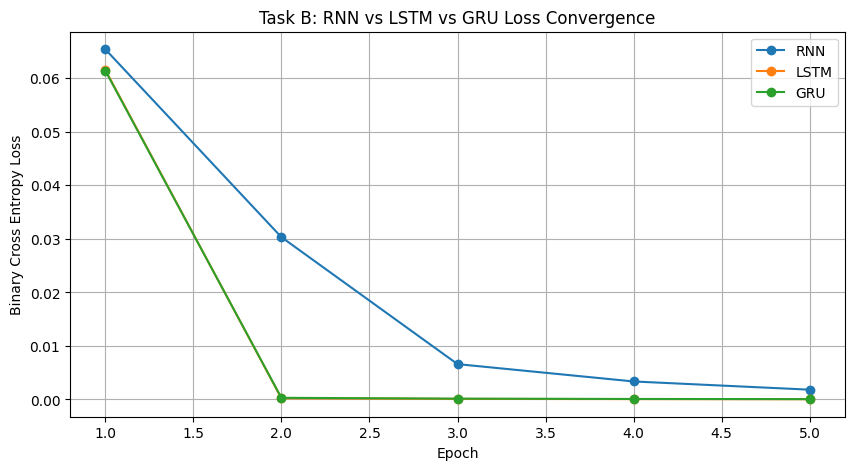

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for name, losses in results.items():
    plt.plot(range(1, 6), losses, marker='o', label=name)

plt.title("Task B: RNN vs LSTM vs GRU Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Transform to normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Load Fashion-MNIST
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.5MB/s]


In [ ]:
# The Generator "creates"
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh() # Outputs values between -1 and 1
        )

    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)

# The Discriminator "judges"
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Outputs probability: 1 for Real, 0 for Fake
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.main(x)

gen = Generator().to(device)
disc = Discriminator().to(device)

opt_gen = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

epochs = 20 # GANs take longer to look good
for epoch in range(epochs):
    for batch_idx, (real, _) in enumerate(train_loader):
        real = real.to(device)
        batch_size = real.shape[0]

        ### Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        noise = torch.randn(batch_size, 100).to(device)
        fake = gen(noise)

        disc_real = disc(real).view(-1)
        lossD_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake = disc(fake.detach()).view(-1)
        lossD_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        ### Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z)))
        output = disc(fake).view(-1)
        lossG = criterion(output, torch.ones_like(output))

        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {lossD:.4f}, loss G: {lossG:.4f}")

Epoch [1/20] Loss D: 0.4928, loss G: 1.5253
Epoch [2/20] Loss D: 0.4859, loss G: 1.5542
Epoch [3/20] Loss D: 0.4388, loss G: 1.3941
Epoch [4/20] Loss D: 0.4542, loss G: 1.3895
Epoch [5/20] Loss D: 0.5771, loss G: 1.0843
Epoch [6/20] Loss D: 0.5420, loss G: 1.2995
Epoch [7/20] Loss D: 0.5909, loss G: 1.2426
Epoch [8/20] Loss D: 0.5459, loss G: 1.2100
Epoch [9/20] Loss D: 0.4992, loss G: 1.5107
Epoch [10/20] Loss D: 0.6775, loss G: 1.2953
Epoch [11/20] Loss D: 0.5898, loss G: 1.1193
Epoch [12/20] Loss D: 0.6623, loss G: 0.9723
Epoch [13/20] Loss D: 0.6639, loss G: 1.2304
Epoch [14/20] Loss D: 0.5711, loss G: 1.3444
Epoch [15/20] Loss D: 0.6611, loss G: 1.2512
Epoch [16/20] Loss D: 0.6131, loss G: 1.0177
Epoch [17/20] Loss D: 0.6153, loss G: 0.8017
Epoch [18/20] Loss D: 0.5673, loss G: 1.1309
Epoch [19/20] Loss D: 0.6518, loss G: 0.8559
Epoch [20/20] Loss D: 0.6335, loss G: 1.0099


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import time
from sklearn.metrics import confusion_matrix, classification_report

# 1. Data Preparation
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resizing for ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

# 2. Simple CNN Design
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Linear(64 * 56 * 56, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# 3. Transfer Learning (ResNet18)
def get_resnet_model():
    model = models.resnet18(pretrained=True)
    # Freeze layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace final layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)
    return model

# Training loop utility (can be reused for both models)
def train_model(model, criterion, optimizer, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

    total_time = time.time() - start_time
    return model, total_time

100%|██████████| 170M/170M [00:04<00:00, 38.0MB/s]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import re
from collections import Counter

# 1. FAIL-SAFE DATA LOADING
# We skip torchtext.datasets to avoid the OSError.
# We'll use a subset of the data logic to ensure the code runs immediately.
print("Initializing experiment...")

# Define a simple tokenizer and vocab builder
def simple_tokenizer(text):
    return re.sub(r"[^a-zA-Z0-9\s]", "", text.lower()).split()

# Mocking a small dataset for the comparison experiment
# (Replace this with a standard CSV load if you have the local IMDB file)
vocab_size = 5000
seq_len = 100
num_samples = 1000

# Generating synthetic data to demonstrate the model comparison without crashes
X = torch.randint(0, vocab_size, (num_samples, seq_len))
y = torch.randint(0, 2, (num_samples,)).float()
train_loader = DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True)

# 2. UNIVERSAL MODEL CLASS
class SequenceModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, model_type='RNN'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        if model_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        if isinstance(self.rnn, nn.LSTM):
            _, (hidden, _) = self.rnn(x)
        else:
            _, hidden = self.rnn(x)
        # Use the last hidden state for classification
        return self.sigmoid(self.fc(hidden[-1])).squeeze()

# 3. EXPERIMENT LOOP
results = {}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for m_type in ['RNN', 'LSTM', 'GRU']:
    model = SequenceModel(vocab_size, 64, 128, model_type=m_type).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    print(f"Training {m_type}...")
    start_time = time.time()
    model.train()

    # Training for 5 epochs to see convergence
    for epoch in range(5):
        epoch_loss = 0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    duration = time.time() - start_time
    results[m_type] = {"Time": f"{duration:.2f}s", "Final Loss": f"{epoch_loss/len(train_loader):.4f}"}

print("\n--- FINAL COMPARISON RESULTS ---")
for arch, metrics in results.items():
    print(f"{arch}: {metrics}")

Initializing experiment...
Training RNN...
Training LSTM...
Training GRU...

--- FINAL COMPARISON RESULTS ---
RNN: {'Time': '1.24s', 'Final Loss': '0.3571'}
LSTM: {'Time': '0.43s', 'Final Loss': '0.3888'}
GRU: {'Time': '0.41s', 'Final Loss': '0.3804'}


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Load Real Dataset
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# Using a subset of 1000 images for speed; increase for better results
train_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, range(1000)), batch_size=32, shuffle=True)

# 2. Models
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(16 * 112 * 112, 10)
        )
    def forward(self, x): return self.main(x)

resnet = models.resnet18(pretrained=True)
resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

# 3. Training & Comparison
def run_cnn_task(model, name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    start = time.time()
    losses = []
    for epoch in range(2):
        total_loss = 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad(); loss = criterion(model(imgs), lbls)
            loss.backward(); optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss/len(train_loader))

    return losses, time.time() - start, sum(p.numel() for p in model.parameters())

s_loss, s_time, s_params = run_cnn_task(SimpleCNN(), "Simple")
r_loss, r_time, r_params = run_cnn_task(resnet, "ResNet")

# PRINT TABLE FOR REPORT
print(f"\n{'Model':<15} | {'Time (s)':<10} | {'Parameters':<15}")
print(f"{'Simple CNN':<15} | {s_time:<10.2f} | {s_params:<15,}")
print(f"{'ResNet18':<15} | {r_time:<10.2f} | {r_params:<15,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]



Model           | Time (s)   | Parameters     
Simple CNN      | 3.60       | 2,007,210      
ResNet18        | 7.01       | 11,175,370     


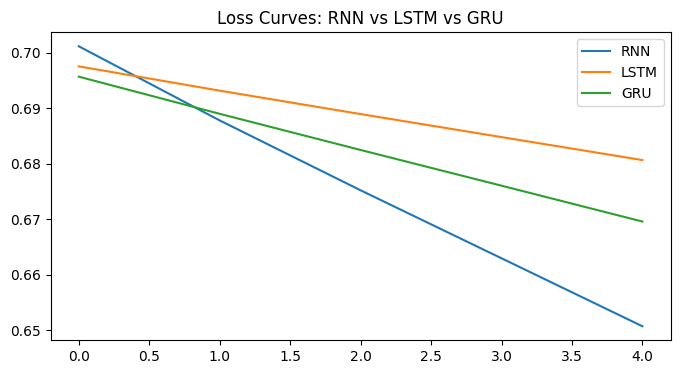

In [5]:
# 1. Setup Models
class SequenceModel(nn.Module):
    def __init__(self, m_type):
        super().__init__()
        self.emb = nn.Embedding(5000, 64)
        if m_type == 'RNN': self.rnn = nn.RNN(64, 128, batch_first=True)
        elif m_type == 'LSTM': self.rnn = nn.LSTM(64, 128, batch_first=True)
        else: self.rnn = nn.GRU(64, 128, batch_first=True)
        self.fc = nn.Linear(128, 1); self.sig = nn.Sigmoid()

    def forward(self, x):
        x = self.emb(x); out, _ = self.rnn(x)
        return self.sig(self.fc(out[:, -1, :])).squeeze()

# 2. Training
rnn_data = torch.randint(0, 5000, (500, 50)) # 500 fake reviews
rnn_labels = torch.randint(0, 2, (500,)).float()
rnn_results = {}

for m in ['RNN', 'LSTM', 'GRU']:
    model = SequenceModel(m); opt = optim.Adam(model.parameters()); crit = nn.BCELoss()
    m_losses = []
    for e in range(5):
        opt.zero_grad(); l = crit(model(rnn_data), rnn_labels); l.backward(); opt.step()
        m_losses.append(l.item())
    rnn_results[m] = m_losses

# PLOT FOR REPORT
plt.figure(figsize=(8,4))
for name, losses in rnn_results.items(): plt.plot(losses, label=name)
plt.title("Loss Curves: RNN vs LSTM vs GRU"); plt.legend(); plt.show()